In [1]:
from __future__ import annotations

import sys
import os
sys.path.insert(0, "/home/xle/agentic-xle")
sys.path.insert(0, "/home/xle/lerobot/src")

# All camera + YOLO logic lives in yolo_camera.py
from yolo_camera import (
    observe_screws,
    capture_frame,
    run_yolo_detection,
    reset_camera,
    MAX_SCREWS,
)

import base64
import io
import logging
import cv2
import numpy as np
from PIL import Image as PILImage
from typing import Any

logger = logging.getLogger(__name__)


In [2]:
# Camera singleton managed by yolo_camera.py — see reset_camera() to reconnect


In [3]:
# capture_frame() is now imported from yolo_camera.py


In [4]:
# YOLO model and detection logic is now in yolo_camera.py


In [5]:
def _observe_with_yolo(
    target_object: str = "screw",
    confidence_threshold: float = 0.25,
    **kwargs: Any,
) -> dict:
    """Thin wrapper around observe_screws() for notebook compatibility."""
    return observe_screws(target_object=target_object, confidence_threshold=confidence_threshold)


In [6]:
_observe_with_yolo(target_object="screw")

[YOLO_WORLD init] Successfully initialized with weight_file_path='/home/xle/arpa_vision/arpa_vision/scripts/yolov8x-worldv2_best.pt'
YOLOv8x-worldv2 summary (fused): 127 layers, 72,856,217 parameters, 0 gradients, 275.1 GFLOPs


NvMapMemAllocInternalTagged: 1075072515 error 12
NvMapMemHandleAlloc: error 0


[YOLO] 2 detections: {'Screw': 2}


{'detected': [{'id': 'screw_0',
   'label': 'Screw',
   'confidence': 0.935,
   'bbox_px': [454, 115, 476, 132],
   'x': 0.2266,
   'y': -0.2427,
   'z': 0.517},
  {'id': 'screw_1',
   'label': 'Screw',
   'confidence': 0.934,
   'bbox_px': [327, 112, 348, 130],
   'x': 0.0273,
   'y': -0.2479,
   'z': 0.516}],
 'count': 2,
 'screw_xyz': array([     0.2266,     -0.2427,       0.517,      0.0273,     -0.2479,       0.516,           0,           0,           0,           0,           0,           0,           0,           0,           0], dtype=float32),
 'frame_b64': '...',
 'depth_status': 'enabled',
 'error': ''}

---

[YOLO] 3 detections: {'Screw': 3}


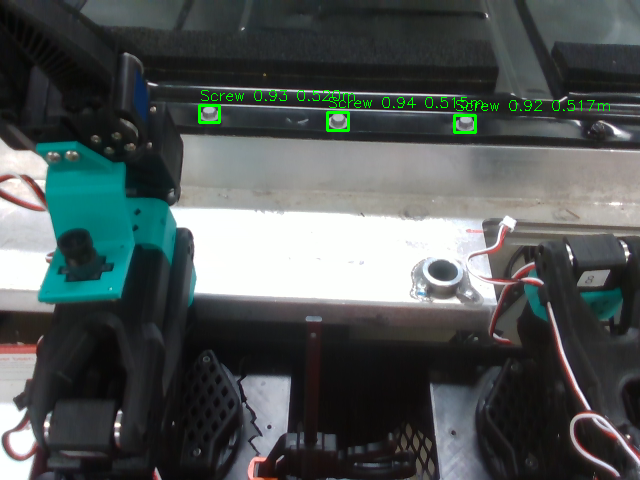

In [8]:
from IPython.display import display, Image
from base64 import b64decode

# 1. Get the observation
obs = _observe_with_yolo(target_object="screw")

# 2. Extract and decode the base64 string
if obs["frame_b64"]:
    image_data = b64decode(obs["frame_b64"])
    display(Image(data=image_data))
else:
    print(f"Error: {obs['error']}")